In [1]:
import sinter
import stim
from typing import List
from mwpf import SinterMWPFDecoder
import matplotlib.pyplot as plt


In [ ]:


noise = [0.01, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
code_distance = [3, 5, 7, 9]

# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    dict(
    circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={'d': d, 'p': p, 'label': 'rotated_memory_x'},
    )
    for d in code_distance
    for p in noise
]

tasks = [
    sinter.Task(**task)
    for task in task_configs
]

pymatching_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders = ["pymatching"],
    max_shots=10000,
    max_errors=500,
)
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)
# ax.set_ylim(1e-1, 1e-0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title("Surface Code Error Rates (PyMatching, Init |+>, Measure X Basis)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120) 


In [ ]:
noise = [0.01, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
code_distance = [3, 5, 7, 9]

# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    dict(
    circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={'d': d, 'p': p, 'label': 'rotated_memory_x'},
    )
    for d in code_distance
    for p in noise
]

tasks = [
    sinter.Task(**task)
    for task in task_configs
]

mwpf_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders = ["mwpf"],
    custom_decoders = { "mwpf": SinterMWPFDecoder(cluster_node_limit=50) },
    max_shots=10000,
    max_errors=500,
    print_progress=True
)


KeyboardInterrupt: 

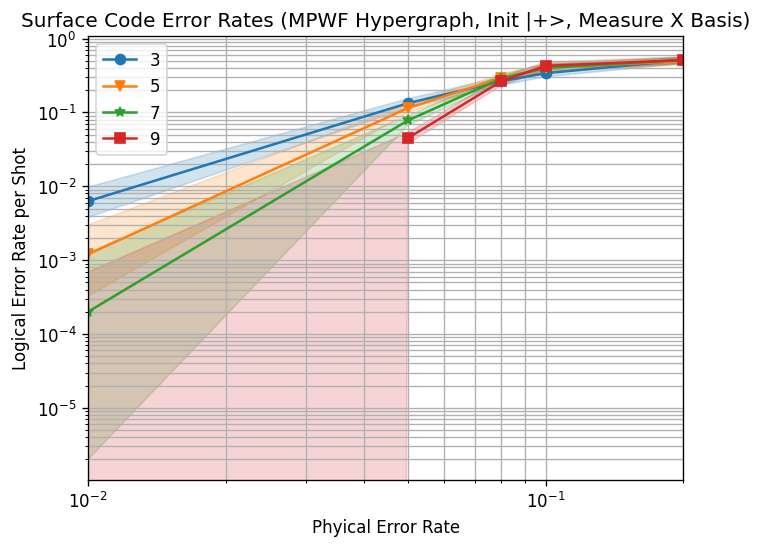

In [39]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=mwpf_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)
# ax.set_ylim(1e-1, 1e-0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title("Surface Code Error Rates (MPWF Hypergraph, Init |+>, Measure X Basis)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120) 


In [2]:
import itertools
from uuid import uuid4


from dataclasses import replace
import mwpf.ref_circuit

# TODO - if we use individual errors e.g. X_ERROR Y_ERROR Z_ERROR instead of randomized DEPOLARIZE1/2 noise
CONVERT_TO_ERASURE_NOISE = ("DEPOLARIZE1", "DEPOLARIZE2")

def erasure_conversion(task_config: dict, conversion_factor:int=1, add_detectors:bool=True) -> dict:
    """Converts random pauli noise instructions (e.g. DEPOLARIZE1, DEPOLARIZE2) to HERALDED_ERASE instructions

    See notes in https://github.com/yuewuo/mwpf/blob/main/src/python/mwpf/ref_circuit.py
    for explanation of why reference circuits are needed to keep track of measurement indices w/ heralded errors
    """
    circuit = task_config["circuit"]
    json_metadata = task_config["json_metadata"]
    ref_circuit = mwpf.ref_circuit.RefCircuit.of(circuit)

    instructions: list[mwpf.ref_circuit.RefInstruction] = []
    for instruction in ref_circuit:
        if instruction.name in CONVERT_TO_ERASURE_NOISE:
            p =  instruction.gate_args[0]
            instructions.append(replace(instruction, gate_args=[p * conversion_factor]))
            new_instruction = mwpf.ref_circuit.RefInstruction.new_heralded_erase(
                instruction.targets, min(1, 4 / 3 * p *conversion_factor)
            )
            instructions.append(new_instruction)
            if add_detectors is True:
                for rec in new_instruction.recs:
                    instructions.append(mwpf.ref_circuit.RefInstruction.new_detector((rec,)))
        else:
            instructions.append(instruction)
    converted_metadata = json_metadata.copy()
    converted_metadata["p_erase"] = converted_metadata["p"]
    converted_metadata["p"] = 0
    run_id = converted_metadata["run_id"]

    converted_circuit = mwpf.ref_circuit.RefCircuit.of(instructions).circuit() 
    new_task_config = dict(
        circuit=converted_circuit,
        json_metadata=converted_metadata,
        decoder=f"mwpf__{run_id}"
    )
    return new_task_config

noise = [0.01, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
code_distance = [3, 5, 7]

# `rotated_memory_x` (surface_code):
# Initialize a logical `|+>` in a rotated surface code,
# preserve it against noise for the given number of rounds,
# then measure in the X basis.
task_configs = [
    dict(
    circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_x",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={'d': d, 'p': p, 'label': 'rotated_memory_x', "run_id": str(uuid4())},
    )
    for d in code_distance
    for p in noise
]
converted_erasure_task_configs = list(map(erasure_conversion, task_configs))
tasks = [
    sinter.Task(**task)
    for task in converted_erasure_task_configs
]

def build_custom_decoders(task_configs):
    return {
         f"mwpf__{task_config['json_metadata']['run_id']}": 
         SinterMWPFDecoder(cluster_node_limit=50, with_progress=True).with_circuit(task_config["circuit"])
         for task_config in task_configs
    }

# def sinter_with_custom_decoder(task_config: dict):
#     task = sinter.Task(**task_config)
#     result = sinter.collect(
#         num_workers=1,
#         tasks=[task],
#         custom_decoders = custom_decoders(converted_erasure_task_configs)
#         max_shots=10000,
#         max_errors=100,
#         print_progress=True
#     )
#     return result

# erasure_collected_stats = list(map(sinter_with_custom_decoder, converted_erasure_task_configs))
erasure_collected_stats = sinter.collect(
        num_workers=4,
        tasks=tasks,
        custom_decoders = build_custom_decoders(converted_erasure_task_configs),
        max_shots=10000,
        max_errors=100,
        print_progress=True
    )


Starting 4 workers...
24 tasks left:
  workers                                    decoder eta shots_left errors_left json_metadata                                                                          
        1 mwpf__72967cbf-74c2-4717-86cd-e1e5eff44b22 <1m       8703          81 d=3,p=0,label=rotated_memory_x,run_id=72967cbf-74c2-4717-86cd-e1e5eff44b22,p_erase=0.01
        1 mwpf__4eaca4d6-b9ec-4aed-9a94-6f13f6ad9c4f   ?      10000         100 d=3,p=0,label=rotated_memory_x,run_id=4eaca4d6-b9ec-4aed-9a94-6f13f6ad9c4f,p_erase=0.05
        1 mwpf__53423a25-54a0-4118-a2ed-a84c87deb226   ?      10000         100 d=3,p=0,label=rotated_memory_x,run_id=53423a25-54a0-4118-a2ed-a84c87deb226,p_erase=0.08
        1 mwpf__a7a966dc-178e-481d-8be2-30c275989754   ?      10000         100 d=3,p=0,label=rotated_memory_x,run_id=a7a966dc-178e-481d-8be2-30c275989754,p_erase=0.1 
        0 mwpf__73e2623c-650d-4730-8c45-b6b93efeb7d9 ?·∞      10000         100 d=3,p=0,label=rotated_memory_x,run_id=73e26

In [11]:
erasure_collected_stats[0]

sinter.TaskStats(strong_id='d4a222385b1a2b34370e57c6d39c3d1dbfa3ba9f7c58ef8f97e8b2364faccc2f', decoder='mwpf__72967cbf-74c2-4717-86cd-e1e5eff44b22', json_metadata={'d': 3, 'p': 0, 'label': 'rotated_memory_x', 'run_id': '72967cbf-74c2-4717-86cd-e1e5eff44b22', 'p_erase': 0.01}, shots=7441, errors=114, seconds=0.17595516799883626)

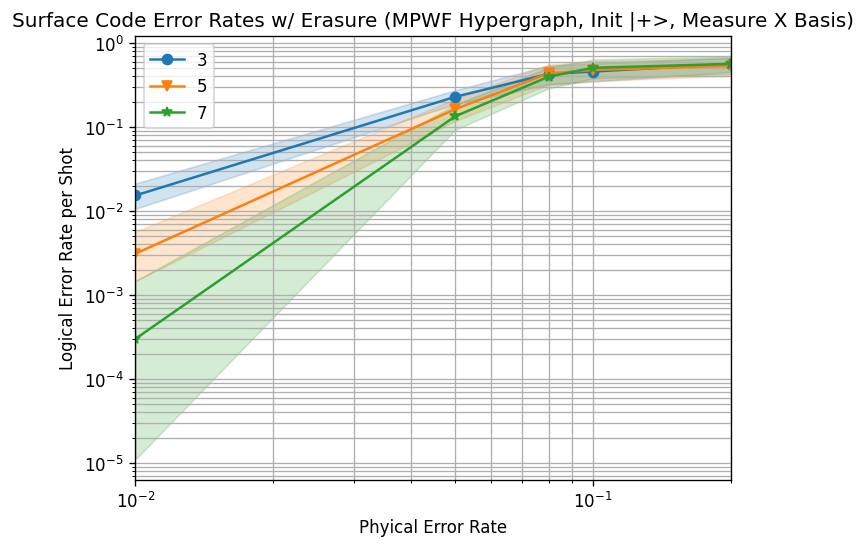

In [13]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_collected_stats,
    x_func=lambda stats: stats.json_metadata['p_erase'],
    group_func=lambda stats: stats.json_metadata['d'],
)
# ax.set_ylim(1e-1, 1e-0)
ax.set_xlim(1e-2, 2e-1)
ax.loglog()
ax.set_title("Surface Code Error Rates w/ Erasure (MPWF Hypergraph, Init |+>, Measure X Basis)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120) 